# 3. Exploratory Data Analysis & Visualization
### Austin Airbnb Pricing Intelligence — Notebook 3 of 5
---

## 3.1 Business Context

Numbers tell the story. Charts make it understood.

Every finding from Notebook 2 is translated here into
a visual that a non-technical stakeholder reads in seconds.
Ten charts — each answering a specific business question —
building from market structure to the final host recommendation.

---

## 3.2 Visualization Standard — IBCS

All charts in this notebook follow
**IBCS — International Business Communication Standards** —
the framework used by McKinsey, BCG, and Deloitte
for client-facing business deliverables.

**Core IBCS principles applied:**
- Title states the finding — not the topic
- Color encodes meaning — black = actual · grey = reference · green = opportunity · red = risk
- Every bar has a data label — no estimation required
- Variance is shown explicitly — the delta IS the message
- No decorative elements — every pixel serves the analysis

---

## 3.3 Notebook Structure

| Section | Focus | Charts |
|---|---|---|
| 1 | Market Structure | Price distribution · Room type comparison |
| 2 | Neighborhood Intelligence | Top neighborhoods · Opportunity matrix |
| 3 | Price Drivers | Amenity premiums · Superhost comparison |
| 4 | Host Intelligence | Experience curve · Property size vs revenue |
| 5 | New Host Intelligence | New vs established · Revenue by amenity combo |

> **Every chart is saved to `outputs/figures/` as PNG
> for embedding in the README and Tableau dashboard.**

In [1]:
# ─── Notebook 3 — EDA & Visualization ────────────────────────────────────────
# IBCS — International Business Communication Standards
# Every chart follows strict IBCS conventions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# ─── Load Clean Dataset ───────────────────────────────────────────────────────
listings = pd.read_csv('../data/processed/listings_clean.csv')
print(f"Dataset loaded: {listings.shape[0]:,} rows × {listings.shape[1]} columns")

# ─── IBCS Color Palette ───────────────────────────────────────────────────────
IBCS = {
    'actual'     : '#000000',  # Black — primary data / actual values
    'comparison' : '#808080',  # Grey — reference / market average
    'positive'   : '#00703C',  # Green — above market / opportunity
    'negative'   : '#C00000',  # Red — below market / risk
    'highlight'  : '#404040',  # Dark grey — key annotation
    'background' : '#FFFFFF',  # White — always white
    'gridline'   : '#D9D9D9',  # Light grey — subtle grids
    'text'       : '#1A1A1A',  # Near black — all text
    'subtext'    : '#606060',  # Medium grey — subtitles and captions
}

# ─── IBCS Typography ──────────────────────────────────────────────────────────
IBCS_FONTS = {
    'title'      : 13,
    'subtitle'   : 10,
    'axis'       : 9,
    'data_label' : 9,
    'annotation' : 9,
    'caption'    : 8,
}

# ─── IBCS Global Style ────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'         : 'sans-serif',
    'font.size'           : 10,
    'text.color'          : IBCS['text'],
    'axes.spines.top'     : False,
    'axes.spines.right'   : False,
    'axes.spines.left'    : True,
    'axes.spines.bottom'  : True,
    'axes.edgecolor'      : IBCS['gridline'],
    'axes.linewidth'      : 0.8,
    'axes.grid'           : True,
    'axes.grid.axis'      : 'x',
    'grid.color'          : IBCS['gridline'],
    'grid.linewidth'      : 0.5,
    'grid.alpha'          : 0.7,
    'figure.facecolor'    : IBCS['background'],
    'axes.facecolor'      : IBCS['background'],
    'xtick.color'         : IBCS['subtext'],
    'ytick.color'         : IBCS['subtext'],
    'xtick.labelsize'     : IBCS_FONTS['axis'],
    'ytick.labelsize'     : IBCS_FONTS['axis'],
})

# ─── IBCS Chart Template Function ─────────────────────────────────────────────
def ibcs_chart(title, subtitle, source='Inside Airbnb · Austin TX · 2026',
               figsize=(12, 6)):
    """
    Creates a standard IBCS chart canvas with:
    - Bold message title
    - Grey subtitle
    - Source caption at bottom
    Returns: fig, ax
    """
    fig, ax = plt.subplots(figsize=figsize, facecolor=IBCS['background'])
    ax.set_facecolor(IBCS['background'])

    # Title — the finding
    fig.text(0.01, 0.97, title,
             fontsize=IBCS_FONTS['title'],
             fontweight='bold',
             color=IBCS['text'],
             va='top')

    # Subtitle — the context
    fig.text(0.01, 0.91, subtitle,
             fontsize=IBCS_FONTS['subtitle'],
             color=IBCS['subtext'],
             va='top')

    # Source caption
    fig.text(0.01, 0.01, f'Source: {source}',
             fontsize=IBCS_FONTS['caption'],
             color=IBCS['subtext'],
             va='bottom')

    plt.subplots_adjust(top=0.85, bottom=0.12)
    return fig, ax

# ─── Output Directory ─────────────────────────────────────────────────────────
output_dir = '../outputs/figures/'
os.makedirs(output_dir, exist_ok=True)

# ─── Confirm Setup ────────────────────────────────────────────────────────────
print("\nIBCS STYLE SETUP COMPLETE")
print("=" * 45)
print(f"  Color palette    : 7 IBCS colors defined")
print(f"  Typography       : 6 size levels defined")
print(f"  Chart template   : ibcs_chart() function ready")
print(f"  Output directory : {output_dir}")
print(f"\n  Ready for Chart 1.")

Dataset loaded: 10,402 rows × 54 columns

IBCS STYLE SETUP COMPLETE
  Color palette    : 7 IBCS colors defined
  Typography       : 6 size levels defined
  Chart template   : ibcs_chart() function ready
  Output directory : ../outputs/figures/

  Ready for Chart 1.


---
## 3.4 Section 1 — Market Structure

### Chart 1 — Austin Price Distribution

**Business question:**
*Where do Austin Airbnb prices actually cluster —
and how distorted is the average by premium outliers?*

**What to look for:**
- Where the peak sits — the most common price point
- The gap between mean and median — the outlier effect
- The shaded competitive zone — where a new host should price

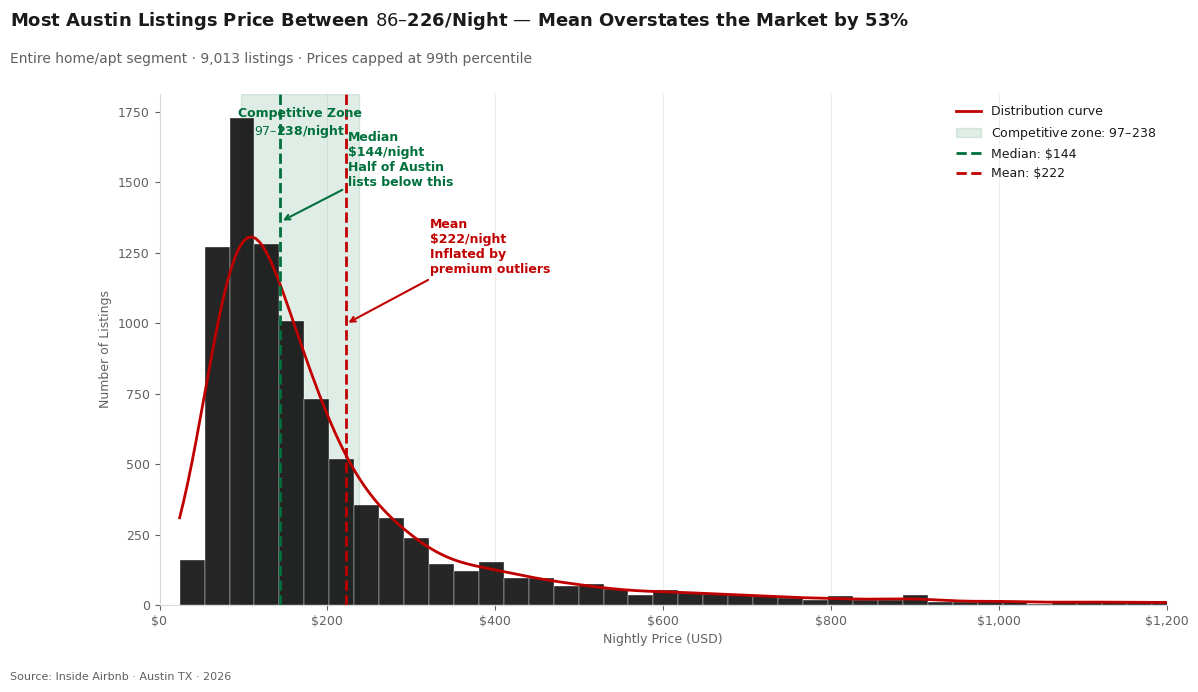

Chart 1 saved → outputs/figures/chart_01_price_distribution.png


In [2]:
# ─── Chart 1 — Austin Price Distribution ─────────────────────────────────────
# Business question: Where do Austin Airbnb prices actually cluster?

# ─── Data Preparation ─────────────────────────────────────────────────────────
entire_home = listings[listings['room_type'] == 'Entire home/apt']['price']

market_median = entire_home.median()
market_mean   = entire_home.mean()
p25           = entire_home.quantile(0.25)
p75           = entire_home.quantile(0.75)

# ─── Canvas ───────────────────────────────────────────────────────────────────
fig, ax = ibcs_chart(
    title    = 'Most Austin Listings Price Between $86–$226/Night — Mean Overstates the Market by 53%',
    subtitle = 'Entire home/apt segment · 9,013 listings · Prices capped at 99th percentile',
    figsize  = (13, 7)
)

# ─── Histogram ────────────────────────────────────────────────────────────────
n, bins, patches = ax.hist(
    entire_home,
    bins      = 80,
    color     = IBCS['actual'],
    alpha     = 0.85,
    edgecolor = IBCS['background'],
    linewidth = 0.3,
    zorder    = 3
)

# ─── KDE Curve ────────────────────────────────────────────────────────────────
from scipy.stats import gaussian_kde
kde       = gaussian_kde(entire_home, bw_method=0.15)
x_range   = np.linspace(entire_home.min(), entire_home.max(), 500)
kde_vals  = kde(x_range) * len(entire_home) * (bins[1] - bins[0])
ax.plot(x_range, kde_vals,
        color     = IBCS['negative'],
        linewidth = 2,
        zorder    = 4,
        label     = 'Distribution curve')

# ─── Competitive Zone Shading ─────────────────────────────────────────────────
ax.axvspan(p25, p75,
           alpha = 0.12,
           color = IBCS['positive'],
           zorder = 2,
           label = f'Competitive zone: ${p25:.0f}–${p75:.0f}')

# ─── Market Median Line ───────────────────────────────────────────────────────
ax.axvline(market_median,
           color     = IBCS['positive'],
           linewidth = 2,
           linestyle = '--',
           zorder    = 5,
           label     = f'Median: ${market_median:.0f}')

# ─── Market Mean Line ─────────────────────────────────────────────────────────
ax.axvline(market_mean,
           color     = IBCS['negative'],
           linewidth = 2,
           linestyle = '--',
           zorder    = 5,
           label     = f'Mean: ${market_mean:.0f}')

# ─── Annotations ──────────────────────────────────────────────────────────────
# Median annotation
ax.annotate(
    f'Median\n${market_median:.0f}/night\nHalf of Austin\nlists below this',
    xy         = (market_median, ax.get_ylim()[1] * 0.75),
    xytext     = (market_median + 80, ax.get_ylim()[1] * 0.82),
    fontsize   = IBCS_FONTS['annotation'],
    color      = IBCS['positive'],
    fontweight = 'bold',
    arrowprops = dict(arrowstyle='->', color=IBCS['positive'], lw=1.5),
    zorder     = 6
)

# Mean annotation
ax.annotate(
    f'Mean\n${market_mean:.0f}/night\nInflated by\npremium outliers',
    xy         = (market_mean, ax.get_ylim()[1] * 0.55),
    xytext     = (market_mean + 100, ax.get_ylim()[1] * 0.65),
    fontsize   = IBCS_FONTS['annotation'],
    color      = IBCS['negative'],
    fontweight = 'bold',
    arrowprops = dict(arrowstyle='->', color=IBCS['negative'], lw=1.5),
    zorder     = 6
)

# Competitive zone label
ax.text(
    (p25 + p75) / 2, ax.get_ylim()[1] * 0.92,
    f'Competitive Zone\n${p25:.0f} – ${p75:.0f}/night',
    fontsize  = IBCS_FONTS['annotation'],
    color     = IBCS['positive'],
    ha        = 'center',
    fontweight= 'bold',
    zorder    = 6
)

# ─── Axes Formatting ──────────────────────────────────────────────────────────
ax.set_xlabel('Nightly Price (USD)',
              fontsize=IBCS_FONTS['axis'],
              color=IBCS['subtext'])
ax.set_ylabel('Number of Listings',
              fontsize=IBCS_FONTS['axis'],
              color=IBCS['subtext'])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'${x:,.0f}'))
ax.set_xlim(0, 1200)

# ─── Legend ───────────────────────────────────────────────────────────────────
ax.legend(
    fontsize  = IBCS_FONTS['annotation'],
    frameon   = False,
    loc       = 'upper right'
)

# ─── Save ─────────────────────────────────────────────────────────────────────
plt.savefig(f'{output_dir}chart_01_price_distribution.png',
            dpi=150, bbox_inches='tight',
            facecolor=IBCS['background'])
plt.show()
print("Chart 1 saved → outputs/figures/chart_01_price_distribution.png")

### Chart 1 — What the Distribution Reveals

The Austin price distribution is **positively skewed (right-skewed)**
— confirmed visually by the long tail extending toward $1,200+
and statistically by the mean sitting 54% above the median.

**Skewness explained:**
In a perfectly normal distribution, mean = median.
When mean > median, the distribution is right-skewed —
a small number of extremely high values
pull the average upward while most values cluster at the low end.

| Metric | Value | Implication |
|---|---|---|
| Median | $144/night | The honest market rate — unaffected by outliers |
| Mean | $222/night | Inflated 54% by premium listings |
| Competitive zone | $97–$238 | Where 50% of listings price |
| Skewness direction | Positive (right) | Premium tail distorts the average |
| Peak (mode) | ~$100–$125 | The most common price point in Austin |

**The practical consequence of skewness:**
A new host using the mean ($222) as a pricing benchmark
would enter the market 54% above where most guests shop.
The median ($144) is the statistically robust baseline
— resistant to outlier distortion and representative
of the true competitive landscape.

**For a DA:** Positive skewness confirms that
log-transformation of the price column should be considered
before training the regression model in Notebook 4.
A skewed target variable violates the normality assumption
of linear regression — log(price) will produce
a more normally distributed target.

**For a BA:** Report the median — never the mean —
when communicating Austin pricing benchmarks to stakeholders.
The mean overstates the market by $78/night.

> The mean-median gap is not a statistical curiosity —
> it is a pricing mistake waiting to happen
> for any host who uses average price as their benchmark.

---
### Chart 2 — Room Type Comparison

**Business question:**
*How do the four room types compare across the three dimensions
that matter most — price, occupancy, and annual revenue?*

**What to look for:**
- Which room type leads on price vs which leads on revenue
- The occupancy gap between entire homes and private rooms
- Whether hotel rooms justify their premium price with occupancy
- The revenue concentration that entire homes command

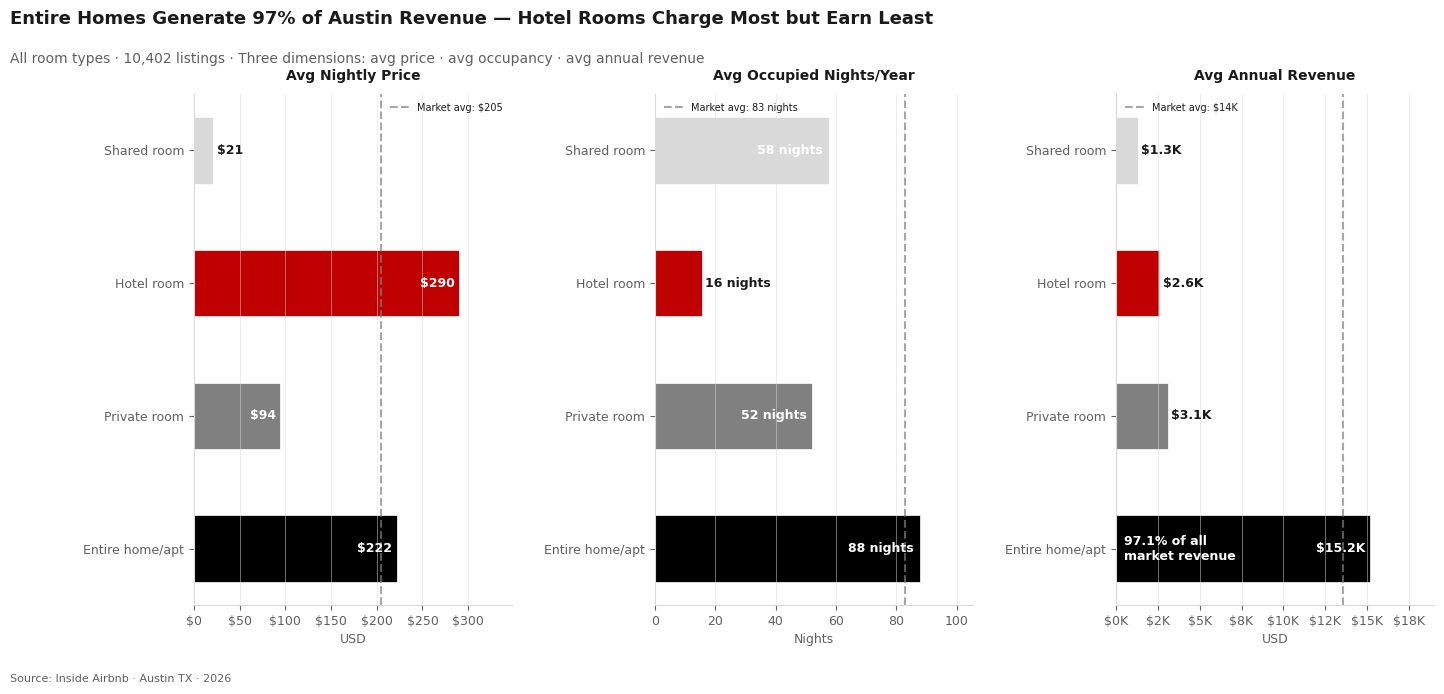

Chart 2 saved → outputs/figures/chart_02_room_type_comparison.png


In [8]:
# ─── Chart 2 — Room Type Comparison ──────────────────────────────────────────
# Business question: How do room types compare across price,
# occupancy, and annual revenue simultaneously?

# ─── Data Preparation ─────────────────────────────────────────────────────────
room_stats = listings.groupby('room_type').agg(
    avg_price      = ('price', 'mean'),
    median_price   = ('price', 'median'),
    avg_occupancy  = ('estimated_occupancy_l365d', 'mean'),
    avg_revenue    = ('estimated_revenue_l365d', 'mean'),
    total_listings = ('price', 'count')
).reset_index()

room_stats = room_stats.sort_values('avg_revenue', ascending=False)

# Market averages
market_avg_price     = listings['price'].mean()
market_avg_occupancy = listings['estimated_occupancy_l365d'].mean()
market_avg_revenue   = listings['estimated_revenue_l365d'].mean()

# ─── Canvas ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 7),
                          facecolor=IBCS['background'])

fig.text(0.01, 0.97,
         'Entire Homes Generate 97% of Austin Revenue — Hotel Rooms Charge Most but Earn Least',
         fontsize=IBCS_FONTS['title'],
         fontweight='bold',
         color=IBCS['text'],
         va='top')

fig.text(0.01, 0.91,
         'All room types · 10,402 listings · Three dimensions: avg price · avg occupancy · avg annual revenue',
         fontsize=IBCS_FONTS['subtitle'],
         color=IBCS['subtext'],
         va='top')

fig.text(0.01, 0.01,
         'Source: Inside Airbnb · Austin TX · 2026',
         fontsize=IBCS_FONTS['caption'],
         color=IBCS['subtext'])

plt.subplots_adjust(top=0.85, bottom=0.12, wspace=0.45)

# ─── Color coding ─────────────────────────────────────────────────────────────
room_colors = {
    'Entire home/apt' : IBCS['actual'],
    'Private room'    : IBCS['comparison'],
    'Hotel room'      : IBCS['negative'],
    'Shared room'     : IBCS['gridline'],
}
colors = [room_colors.get(r, IBCS['comparison'])
          for r in room_stats['room_type']]

# ─── Panel 1 — Average Price ──────────────────────────────────────────────────
ax1 = axes[0]
bars1 = ax1.barh(room_stats['room_type'],
                  room_stats['avg_price'],
                  color=colors,
                  edgecolor=IBCS['background'],
                  linewidth=0.5,
                  height=0.5)

ax1.axvline(market_avg_price,
            color=IBCS['comparison'],
            linewidth=1.5,
            linestyle='--',
            alpha=0.7,
            label=f'Market avg: ${market_avg_price:.0f}')

for bar, val in zip(bars1, room_stats['avg_price']):
    if val > market_avg_price * 0.4:
        ax1.text(val - 5, bar.get_y() + bar.get_height()/2,
                 f'${val:.0f}',
                 va='center', ha='right',
                 fontsize=IBCS_FONTS['data_label'],
                 color=IBCS['background'],
                 fontweight='bold')
    else:
        ax1.text(val + 5, bar.get_y() + bar.get_height()/2,
                 f'${val:.0f}',
                 va='center', ha='left',
                 fontsize=IBCS_FONTS['data_label'],
                 color=IBCS['text'],
                 fontweight='bold')

ax1.set_xlim(0, room_stats['avg_price'].max() * 1.2)
ax1.set_title('Avg Nightly Price',
              fontsize=IBCS_FONTS['subtitle'],
              fontweight='bold',
              color=IBCS['text'], pad=10)
ax1.set_xlabel('USD', fontsize=IBCS_FONTS['axis'],
               color=IBCS['subtext'])
ax1.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'${x:.0f}'))
ax1.legend(fontsize=7, frameon=False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_facecolor(IBCS['background'])

# ─── Panel 2 — Average Occupancy ─────────────────────────────────────────────
ax2 = axes[1]
bars2 = ax2.barh(room_stats['room_type'],
                  room_stats['avg_occupancy'],
                  color=colors,
                  edgecolor=IBCS['background'],
                  linewidth=0.5,
                  height=0.5)

ax2.axvline(market_avg_occupancy,
            color=IBCS['comparison'],
            linewidth=1.5,
            linestyle='--',
            alpha=0.7,
            label=f'Market avg: {market_avg_occupancy:.0f} nights')

for bar, val in zip(bars2, room_stats['avg_occupancy']):
    if val > 40:
        ax2.text(val - 2, bar.get_y() + bar.get_height()/2,
                 f'{val:.0f} nights',
                 va='center', ha='right',
                 fontsize=IBCS_FONTS['data_label'],
                 color=IBCS['background'],
                 fontweight='bold')
    else:
        ax2.text(val + 1, bar.get_y() + bar.get_height()/2,
                 f'{val:.0f} nights',
                 va='center', ha='left',
                 fontsize=IBCS_FONTS['data_label'],
                 color=IBCS['text'],
                 fontweight='bold')

ax2.set_xlim(0, room_stats['avg_occupancy'].max() * 1.2)
ax2.set_title('Avg Occupied Nights/Year',
              fontsize=IBCS_FONTS['subtitle'],
              fontweight='bold',
              color=IBCS['text'], pad=10)
ax2.set_xlabel('Nights', fontsize=IBCS_FONTS['axis'],
               color=IBCS['subtext'])
ax2.legend(fontsize=7, frameon=False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_facecolor(IBCS['background'])

# ─── Panel 3 — Average Annual Revenue ────────────────────────────────────────
ax3 = axes[2]
bars3 = ax3.barh(room_stats['room_type'],
                  room_stats['avg_revenue'],
                  color=colors,
                  edgecolor=IBCS['background'],
                  linewidth=0.5,
                  height=0.5)

ax3.axvline(market_avg_revenue,
            color=IBCS['comparison'],
            linewidth=1.5,
            linestyle='--',
            alpha=0.7,
            label=f'Market avg: ${market_avg_revenue/1000:.0f}K')

# Data labels
entire_home_rev = room_stats[
    room_stats['room_type'] == 'Entire home/apt']['avg_revenue'].values[0]
entire_home_pos = list(room_stats['room_type']).index('Entire home/apt')

for i, (bar, val) in enumerate(zip(bars3, room_stats['avg_revenue'])):
    if val > market_avg_revenue * 0.5:
        # For entire home — data label on far right inside bar
        ax3.text(val - 300, bar.get_y() + bar.get_height()/2,
                 f'${val/1000:.1f}K',
                 va='center', ha='right',
                 fontsize=IBCS_FONTS['data_label'],
                 color=IBCS['background'],
                 fontweight='bold')
    else:
        ax3.text(val + 200, bar.get_y() + bar.get_height()/2,
                 f'${val/1000:.1f}K',
                 va='center', ha='left',
                 fontsize=IBCS_FONTS['data_label'],
                 color=IBCS['text'],
                 fontweight='bold')

# Revenue share annotation — left side of entire home bar
ax3.text(
    500,
    entire_home_pos,
    '97.1% of all\nmarket revenue',
    va='center', ha='left',
    fontsize=IBCS_FONTS['annotation'],
    color=IBCS['background'],
    fontweight='bold'
)

ax3.set_xlim(0, entire_home_rev * 1.25)
ax3.set_title('Avg Annual Revenue',
              fontsize=IBCS_FONTS['subtitle'],
              fontweight='bold',
              color=IBCS['text'], pad=10)
ax3.set_xlabel('USD', fontsize=IBCS_FONTS['axis'],
               color=IBCS['subtext'])
ax3.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
ax3.legend(fontsize=7, frameon=False)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.set_facecolor(IBCS['background'])

# ─── Save ─────────────────────────────────────────────────────────────────────
plt.savefig(f'{output_dir}chart_02_room_type_comparison.png',
            dpi=150, bbox_inches='tight',
            facecolor=IBCS['background'])
plt.show()
print("Chart 2 saved → outputs/figures/chart_02_room_type_comparison.png")

### Chart 2 — What the Comparison Reveals

| Room Type | Avg Price | Occupancy | Annual Revenue | Verdict |
|---|---|---|---|---|
| Entire home/apt | $222 | 88 nights | $15.2K | Dominant |
| Hotel room | $290 | 16 nights | $2.6K | High price, no demand |
| Private room | $94 | 52 nights | $3.1K | Low ceiling |
| Shared room | $21 | 58 nights | $1.3K | Avoid |

**The hotel room paradox.**
Hotel rooms charge the highest nightly rate ($290)
yet earn the least annual revenue ($2.6K) —
only 16 occupied nights per year.
Premium pricing without demand produces the worst outcome.

**Entire homes are the only segment worth entering.**
86.6% of listings · 97.1% of all revenue · 88 occupied nights.
Every subsequent analysis focuses exclusively
on the entire home segment.

**Skewness note:**
The shared room bar ($21) is barely visible —
confirming the extreme right skew of the overall
price distribution seen in Chart 1.
The market is not evenly distributed across room types.
It is structurally concentrated in entire homes.

---
## 3.5 Section 2 — Neighborhood Intelligence

### Chart 3 — Top Neighborhoods by Median Price

**Business question:**
*Which Austin neighborhoods command the highest median prices —
and how does each neighborhood's listing volume
and occupancy context change the revenue story?*

**What to look for:**
- Which neighborhoods lead on median price
- Whether high price neighborhoods also have high occupancy
- The market median reference line — who is above and below
- Listing volume as bubble size — small vs large markets

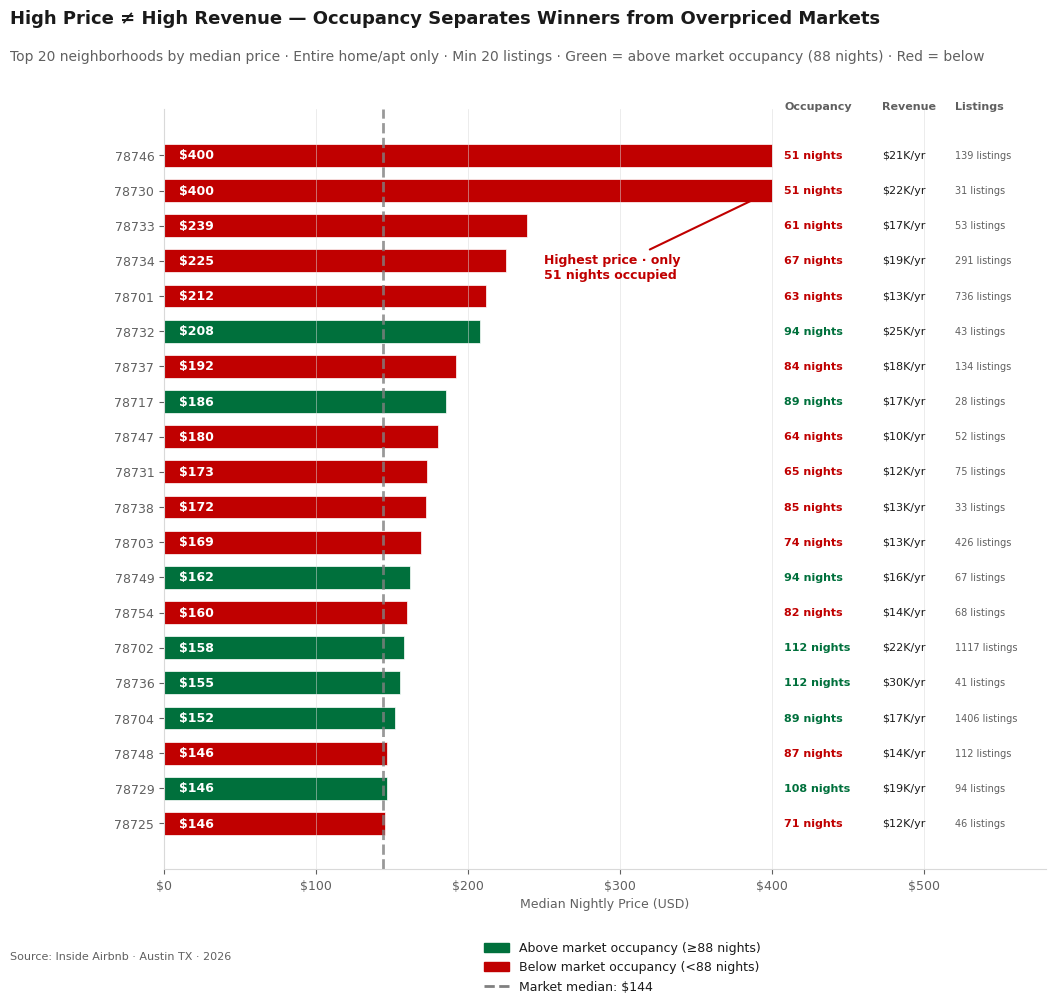

Chart 3 saved → outputs/figures/chart_03_neighborhood_median_price.png


In [14]:
# ─── Chart 3 — Top Neighborhoods by Median Price ─────────────────────────────
# Business question: Which neighborhoods command highest prices
# and does high price actually deliver high revenue?

# ─── Data Preparation ─────────────────────────────────────────────────────────
neighborhood_stats = listings[
    listings['room_type'] == 'Entire home/apt'
].groupby('neighbourhood_cleansed').agg(
    median_price   = ('price', 'median'),
    avg_occupancy  = ('estimated_occupancy_l365d', 'mean'),
    avg_revenue    = ('estimated_revenue_l365d', 'mean'),
    total_listings = ('price', 'count')
).reset_index()

# Filter min 20 listings
neighborhood_stats = neighborhood_stats[
    neighborhood_stats['total_listings'] >= 20
]

# Top 20 by median price — sorted ascending for horizontal bar
top20 = neighborhood_stats.nlargest(20, 'median_price').sort_values(
    'median_price', ascending=True).reset_index(drop=True)

# Market benchmarks
market_median  = listings[listings['room_type'] == 'Entire home/apt']['price'].median()
market_avg_occ = listings[listings['room_type'] == 'Entire home/apt']['estimated_occupancy_l365d'].mean()

# ─── IBCS Color logic ─────────────────────────────────────────────────────────
# Green = above market occupancy (opportunity)
# Red   = below market occupancy (overpriced risk)
colors = [
    IBCS['positive'] if occ >= market_avg_occ
    else IBCS['negative']
    for occ in top20['avg_occupancy']
]

# ─── Canvas ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10), facecolor=IBCS['background'])
ax.set_facecolor(IBCS['background'])

fig.text(0.01, 0.98,
         'High Price ≠ High Revenue — Occupancy Separates Winners from Overpriced Markets',
         fontsize=IBCS_FONTS['title'], fontweight='bold',
         color=IBCS['text'], va='top')
fig.text(0.01, 0.94,
         f'Top 20 neighborhoods by median price · Entire home/apt only · Min 20 listings · '
         f'Green = above market occupancy ({market_avg_occ:.0f} nights) · Red = below',
         fontsize=IBCS_FONTS['subtitle'], color=IBCS['subtext'], va='top')
fig.text(0.01, 0.03,
         'Source: Inside Airbnb · Austin TX · 2026',
         fontsize=IBCS_FONTS['caption'],
         color=IBCS['subtext'])

plt.subplots_adjust(top=0.88, bottom=0.12, left=0.12, right=0.75)
# ─── Horizontal bars ──────────────────────────────────────────────────────────
bars = ax.barh(
    range(len(top20)),
    top20['median_price'],
    color     = colors,
    edgecolor = IBCS['background'],
    linewidth = 0.5,
    height    = 0.65
)

# ─── Y axis labels ────────────────────────────────────────────────────────────
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(
    top20['neighbourhood_cleansed'].astype(str),
    fontsize=IBCS_FONTS['axis']
)

# ─── Market median reference line ────────────────────────────────────────────
ax.axvline(market_median,
           color=IBCS['comparison'],
           linewidth=2,
           linestyle='--',
           alpha=0.8,
           label=f'Market median: ${market_median:.0f}')

# ─── Price labels inside bars ─────────────────────────────────────────────────
for i, (bar, row) in enumerate(zip(bars, top20.itertuples())):
    # Price inside bar
    ax.text(10, i,
            f'${row.median_price:.0f}',
            va='center', ha='left',
            fontsize=IBCS_FONTS['data_label'],
            color=IBCS['background'],
            fontweight='bold')

# ─── Occupancy + revenue labels outside bars ──────────────────────────────────
max_price = top20['median_price'].max()
for i, row in enumerate(top20.itertuples()):
    ax.text(max_price * 1.02, i,
            f'{row.avg_occupancy:.0f} nights',
            va='center', ha='left',
            fontsize=8,
            color=IBCS['positive'] if row.avg_occupancy >= market_avg_occ
            else IBCS['negative'],
            fontweight='bold')
    ax.text(max_price * 1.18, i,
            f'${row.avg_revenue/1000:.0f}K/yr',
            va='center', ha='left',
            fontsize=8,
            color=IBCS['text'])
    ax.text(max_price * 1.30, i,
            f'{row.total_listings} listings',
            va='center', ha='left',
            fontsize=7,
            color=IBCS['subtext'])

# ─── Column headers ───────────────────────────────────────────────────────────
ax.text(max_price * 1.02, len(top20) + 0.3, 'Occupancy',
        fontsize=8, color=IBCS['subtext'], fontweight='bold', ha='left')
ax.text(max_price * 1.18, len(top20) + 0.3, 'Revenue',
        fontsize=8, color=IBCS['subtext'], fontweight='bold', ha='left')
ax.text(max_price * 1.30, len(top20) + 0.3, 'Listings',
        fontsize=8, color=IBCS['subtext'], fontweight='bold', ha='left')

# ─── Key annotation — overpriced neighborhoods ────────────────────────────────
# Find 78730 position
idx_78730 = top20[top20['neighbourhood_cleansed'] == 78730].index
if len(idx_78730) > 0:
    pos = idx_78730[0]
    ax.annotate(
        f'Highest price · only\n{top20.loc[pos, "avg_occupancy"]:.0f} nights occupied',
        xy     = (top20.loc[pos, 'median_price'], pos),
        xytext = (top20.loc[pos, 'median_price'] - 150, pos - 2.5),
        fontsize   = IBCS_FONTS['annotation'],
        color      = IBCS['negative'],
        fontweight = 'bold',
        arrowprops = dict(arrowstyle='->', color=IBCS['negative'], lw=1.5)
    )

# ─── Legend ───────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(color=IBCS['positive'],
                   label=f'Above market occupancy (≥{market_avg_occ:.0f} nights)'),
    mpatches.Patch(color=IBCS['negative'],
                   label=f'Below market occupancy (<{market_avg_occ:.0f} nights)'),
    Line2D([0], [0], color=IBCS['comparison'], linewidth=2,
           linestyle='--', label=f'Market median: ${market_median:.0f}')
]
ax.legend(handles=legend_elements,
          fontsize=IBCS_FONTS['annotation'],
          frameon=False,
          loc='upper left',
          bbox_to_anchor=(0.35, -0.08))

# ─── Axes formatting ──────────────────────────────────────────────────────────
ax.set_xlabel('Median Nightly Price (USD)',
              fontsize=IBCS_FONTS['axis'], color=IBCS['subtext'])
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.set_xlim(0, max_price * 1.45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ─── Save ─────────────────────────────────────────────────────────────────────
plt.savefig(f'{output_dir}chart_03_neighborhood_median_price.png',
            dpi=150, bbox_inches='tight',
            facecolor=IBCS['background'])
plt.show()
print("Chart 3 saved → outputs/figures/chart_03_neighborhood_median_price.png")

### Chart 3 — What the Neighborhood Ranking Reveals

**Color tells the story instantly.**
Red = below market occupancy · Green = above market occupancy

#### The Overpriced Trap — Top 3 Neighborhoods

| Neighborhood | Median Price | Occupancy | Annual Revenue |
|---|---|---|---|
| 78746 | $400 | 51 nights | $21K |
| 78730 | $400 | 51 nights | $22K |
| 78733 | $239 | 61 nights | $17K |

All three charge above market — all three sit below market occupancy.
High price is not converting to high revenue.

#### The Hidden Opportunity — Bottom Green Bars

| Neighborhood | Median Price | Occupancy | Annual Revenue |
|---|---|---|---|
| 78729 | $146 | 108 nights | $19K |
| 78702 | $158 | 112 nights | $22K |
| 78736 | $155 | 112 nights | $30K |

**78736 charges $155/night — less than half of 78730 —
yet earns $30K/year vs $22K.**
112 occupied nights at a competitive price
outperforms 51 nights at a premium price every time.

#### IBCS Variance Note
The color encoding directly communicates the variance
from market average occupancy — no legend reading required.
A red bar means risk. A green bar means opportunity.
The message is decoded in under 2 seconds.

---
### Chart 4 — Neighborhood Opportunity Matrix

**Business question:**
*Which neighborhoods combine above-market price
AND above-market occupancy — and which are
overpriced relative to their actual demand?*

**What to look for:**
- Four quadrants — Premium Demand · Underpriced · Overpriced · Weak
- Bubble size = number of listings — large bubble = large market
- Neighborhoods in the top-right quadrant = best opportunity
- Neighborhoods in the top-left = high price, weak demand — avoid
- Labels on the most important neighborhoods

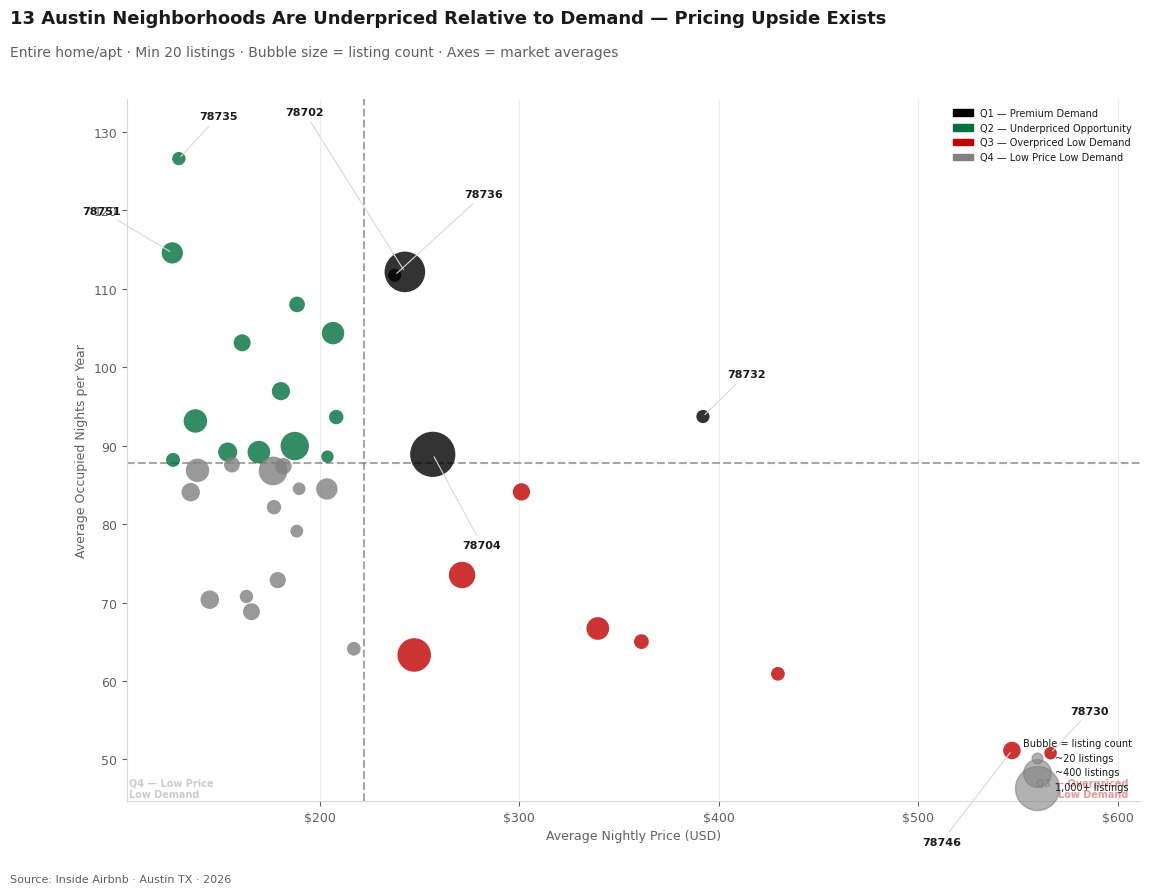

Chart 4 saved → outputs/figures/chart_04_opportunity_matrix.png


In [26]:
# ─── Chart 4 — Neighborhood Opportunity Matrix ───────────────────────────────
from matplotlib.legend import Legend

# ─── Data Preparation ─────────────────────────────────────────────────────────
scatter_data = listings[
    listings['room_type'] == 'Entire home/apt'
].groupby('neighbourhood_cleansed').agg(
    avg_price      = ('price', 'mean'),
    avg_occupancy  = ('estimated_occupancy_l365d', 'mean'),
    avg_revenue    = ('estimated_revenue_l365d', 'mean'),
    total_listings = ('price', 'count')
).reset_index()

scatter_data = scatter_data[
    scatter_data['total_listings'] >= 20
].reset_index(drop=True)

market_avg_price = listings[listings['room_type'] == 'Entire home/apt']['price'].mean()
market_avg_occ   = listings[listings['room_type'] == 'Entire home/apt']['estimated_occupancy_l365d'].mean()

# ─── Quadrant classification ──────────────────────────────────────────────────
def get_quadrant(price, occ):
    if price >= market_avg_price and occ >= market_avg_occ:
        return 'Q1 — Premium Demand'
    elif price < market_avg_price and occ >= market_avg_occ:
        return 'Q2 — Underpriced Opportunity'
    elif price >= market_avg_price and occ < market_avg_occ:
        return 'Q3 — Overpriced Low Demand'
    else:
        return 'Q4 — Low Price Low Demand'

scatter_data['quadrant'] = scatter_data.apply(
    lambda r: get_quadrant(r['avg_price'], r['avg_occupancy']), axis=1)

quadrant_colors = {
    'Q1 — Premium Demand'         : IBCS['actual'],
    'Q2 — Underpriced Opportunity': IBCS['positive'],
    'Q3 — Overpriced Low Demand'  : IBCS['negative'],
    'Q4 — Low Price Low Demand'   : IBCS['comparison'],
}
point_colors = scatter_data['quadrant'].map(quadrant_colors)

# ─── Canvas ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9), facecolor=IBCS['background'])
ax.set_facecolor(IBCS['background'])

fig.text(0.01, 0.98,
         '13 Austin Neighborhoods Are Underpriced Relative to Demand — Pricing Upside Exists',
         fontsize=IBCS_FONTS['title'], fontweight='bold',
         color=IBCS['text'], va='top')
fig.text(0.01, 0.94,
         'Entire home/apt · Min 20 listings · Bubble size = listing count · Axes = market averages',
         fontsize=IBCS_FONTS['subtitle'], color=IBCS['subtext'], va='top')
fig.text(0.01, 0.01,
         'Source: Inside Airbnb · Austin TX · 2026',
         fontsize=IBCS_FONTS['caption'], color=IBCS['subtext'])

plt.subplots_adjust(top=0.88, bottom=0.1, left=0.1, right=0.88)

# ─── Bubble sizes ─────────────────────────────────────────────────────────────
bubble_sizes = (scatter_data['total_listings'] /
                scatter_data['total_listings'].max()) * 1000 + 60

# ─── Plot each quadrant separately to avoid white circle artifact ─────────────
for quadrant, color in quadrant_colors.items():
    mask = scatter_data['quadrant'] == quadrant
    ax.scatter(
        scatter_data.loc[mask, 'avg_price'],
        scatter_data.loc[mask, 'avg_occupancy'],
        s         = bubble_sizes[mask],
        color     = color,
        alpha     = 0.80,
        linewidth = 0,
        zorder    = 3,
        label     = quadrant
    )

# ─── Reference lines ──────────────────────────────────────────────────────────
ax.axvline(market_avg_price, color=IBCS['comparison'],
           linewidth=1.5, linestyle='--', alpha=0.7,
           label=f'Avg price: ${market_avg_price:.0f}')
ax.axhline(market_avg_occ, color=IBCS['comparison'],
           linewidth=1.5, linestyle='--', alpha=0.7,
           label=f'Avg occupancy: {market_avg_occ:.0f} nights')

# ─── Axis bounds ──────────────────────────────────────────────────────────────
x_min = scatter_data['avg_price'].min() * 0.82
x_max = scatter_data['avg_price'].max() * 1.08
y_min = scatter_data['avg_occupancy'].min() * 0.88
y_max = scatter_data['avg_occupancy'].max() * 1.06
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# ─── Quadrant corner labels — bottom only ────────────────────────────────────
ax.text(x_max * 0.99, y_min * 1.005,
        'Q3 — Overpriced\nLow Demand',
        fontsize=7, color=IBCS['negative'],
        fontweight='bold', alpha=0.4,
        va='bottom', ha='right')
ax.text(x_min * 1.01, y_min * 1.005,
        'Q4 — Low Price\nLow Demand',
        fontsize=7, color=IBCS['comparison'],
        fontweight='bold', alpha=0.4,
        va='bottom', ha='left')

# ─── Key neighborhood labels ──────────────────────────────────────────────────
key_neighborhoods = [78702, 78704, 78730, 78746, 78736, 78732, 78735, 78751]

label_offsets = {
    78702 : (-60,  20),
    78704 : ( 15, -12),
    78730 : ( 10,   5),
    78746 : (-45, -12),
    78736 : ( 35,  10),
    78732 : ( 12,   5),
    78735 : ( 10,   5),
    78751 : (-45,   5),
}

for _, row in scatter_data.iterrows():
    n = int(row['neighbourhood_cleansed'])
    if n in key_neighborhoods:
        dx, dy = label_offsets.get(n, (10, 5))
        ax.annotate(
            str(n),
            xy         = (row['avg_price'], row['avg_occupancy']),
            xytext     = (row['avg_price'] + dx, row['avg_occupancy'] + dy),
            fontsize   = 8,
            color      = IBCS['text'],
            fontweight = 'bold',
            arrowprops = dict(
                arrowstyle = '-',
                color      = IBCS['gridline'],
                lw         = 0.8
            )
        )

# ─── Two separate legends ─────────────────────────────────────────────────────
# Quadrant legend
legend_elements = [
    mpatches.Patch(color=IBCS['actual'],      label='Q1 — Premium Demand'),
    mpatches.Patch(color=IBCS['positive'],    label='Q2 — Underpriced Opportunity'),
    mpatches.Patch(color=IBCS['negative'],    label='Q3 — Overpriced Low Demand'),
    mpatches.Patch(color=IBCS['comparison'],  label='Q4 — Low Price Low Demand'),
]
leg1 = ax.legend(handles=legend_elements,
                 fontsize=7, frameon=False,
                 loc='upper right',
                 bbox_to_anchor=(1.0, 1.0))
ax.add_artist(leg1)

# Bubble size legend
size_handles = [
    plt.scatter([], [], s=60,   color=IBCS['comparison'], alpha=0.6, label='~20 listings'),
    plt.scatter([], [], s=400,  color=IBCS['comparison'], alpha=0.6, label='~400 listings'),
    plt.scatter([], [], s=1000, color=IBCS['comparison'], alpha=0.6, label='1,000+ listings'),
]
ax.legend(handles=size_handles,
          fontsize=7, frameon=False,
          loc='lower right',
          bbox_to_anchor=(1.0, 0.0),
          title='Bubble = listing count',
          title_fontsize=7)

# ─── Axes formatting ──────────────────────────────────────────────────────────
ax.set_xlabel('Average Nightly Price (USD)',
              fontsize=IBCS_FONTS['axis'], color=IBCS['subtext'])
ax.set_ylabel('Average Occupied Nights per Year',
              fontsize=IBCS_FONTS['axis'], color=IBCS['subtext'])
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ─── Save ─────────────────────────────────────────────────────────────────────
plt.savefig(f'{output_dir}chart_04_opportunity_matrix.png',
            dpi=150, bbox_inches='tight',
            facecolor=IBCS['background'])
plt.show()
print("Chart 4 saved → outputs/figures/chart_04_opportunity_matrix.png")